<a href="https://colab.research.google.com/github/adityainnet/Instagram-Data-Analysis/blob/main/Instagram_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

plt.style.use('ggplot')
sns.set_style('whitegrid')

In [33]:
users = pd.read_csv("/content/users.csv")
photos = pd.read_csv("/content/photos.csv")
likes = pd.read_csv("/content/likes.csv")
follows = pd.read_csv("/content/follows.csv")
comments = pd.read_csv("/content/comments.csv")
tags = pd.read_csv("/content/tags.csv")
photo_tags = pd.read_csv("/content/photo_tags.csv")

In [34]:
print(users.head())
print(users.shape)

print(photos.head())
print(photos.shape)

print(likes.head())
print(likes.shape)

print(comments.head())
print(comments.shape)

print(tags.head())
print(tags.shape)

print(photo_tags.head())
print(photo_tags.shape)

print(follows.head())
print(follows.shape)

   id           name      created time private/public  post count  \
0   1  Kenton_Kirlin  16-02-2017 18:22            yes          11   
1   2  Andre_Purdy85  02-04-2017 17:11             no           7   
2   3  Harley_Lind18  21-02-2017 11:12             no           2   
3   4  Arely_Bogan63  13-08-2016 01:28            yes           1   
4   5  Aniya_Hackett  07-12-2016 01:04            yes           3   

  Verified status  
0              no  
1              no  
2              no  
3              no  
4              no  
(100, 6)
   id            image link  user ID       created dat Insta filter used  \
0   1     http://elijah.biz        1  13-04-2023 08:04               yes   
1   2    https://shanon.org        1  13-04-2023 08:04                no   
2   3      http://vicky.biz        1  13-04-2023 08:04                no   
3   4      http://oleta.net        1  13-04-2023 08:04                no   
4   5  https://jennings.biz        1  13-04-2023 08:04               yes   


In [35]:
photos['created dat'].nunique()

1

In [36]:
photos['created dat'].head()

,created dat
0,13-04-2023 08:04
1,13-04-2023 08:04
2,13-04-2023 08:04
3,13-04-2023 08:04
4,13-04-2023 08:04


In [37]:
photos['created dat'].tail()

,created dat
252,13-04-2023 08:04
253,13-04-2023 08:04
254,13-04-2023 08:04
255,13-04-2023 08:04
256,13-04-2023 08:04


In [38]:
likes_count = likes.groupby('photo').size().reset_index(name='likes_count')

comments_count = comments.groupby('Photo id').size().reset_index(name='comments_count')

engagement = photos.merge(
    likes_count,
    left_on='id',
    right_on='photo',
    how='left'
)

engagement = engagement.merge(
    comments_count,
    left_on='id',
    right_on='Photo id',
    how='left'
)

engagement['likes_count'] = engagement['likes_count'].fillna(0)

engagement['comments_count'] = engagement['comments_count'].fillna(0)

engagement['engagement_score'] = (
    engagement['likes_count']
    + engagement['comments_count']
)

engagement.head()

,id,image link,user ID,created dat,Insta filter used,photo type,photo,likes_count,Photo id,comments_count,engagement_score
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo,1,25,1,25,50
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo,2,36,2,31,67
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo,3,38,3,27,65
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo,4,38,4,32,70
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo,5,31,5,27,58


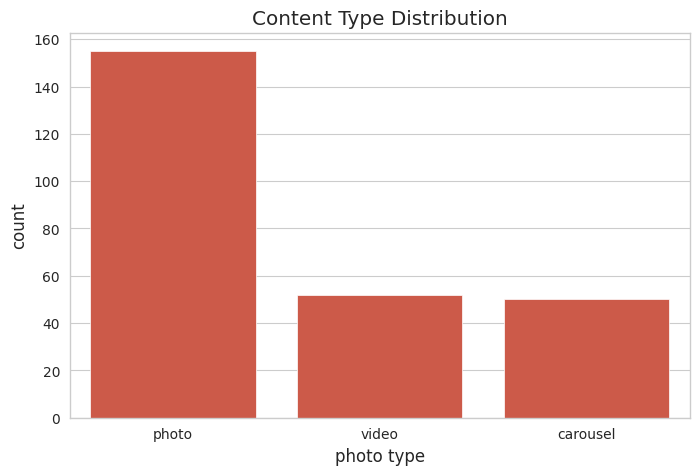

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=photos,
    x='photo type'
)

plt.title('Content Type Distribution')
plt.show()

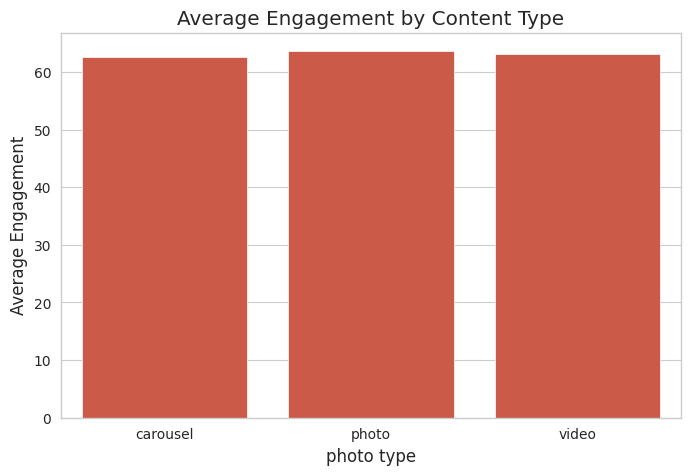

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=engagement.groupby('photo type')['engagement_score'].mean().index,
    y=engagement.groupby('photo type')['engagement_score'].mean().values
)

plt.title('Average Engagement by Content Type')
plt.ylabel('Average Engagement')

plt.show()

In [41]:
hashtags = photo_tags.merge(
    tags,
    left_on='tag ID',
    right_on='id'
)

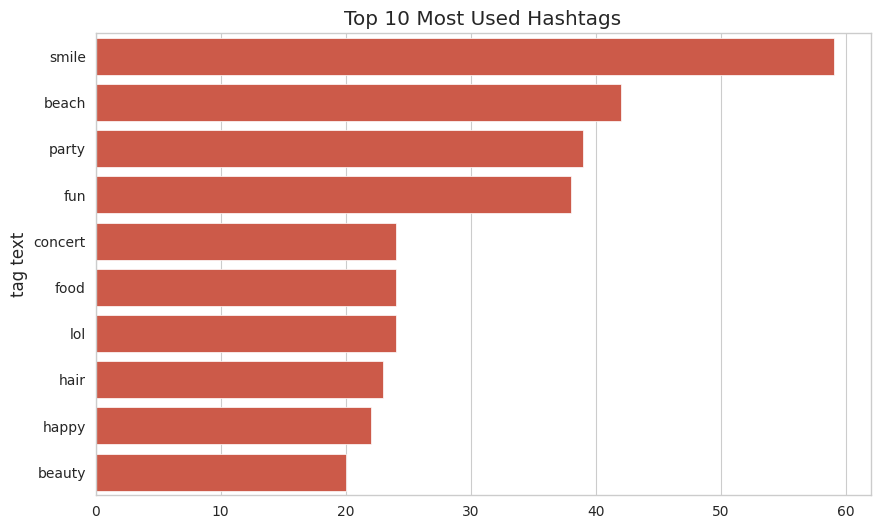

In [42]:
top_tags = hashtags['tag text'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_tags.values,
    y=top_tags.index
)

plt.title('Top 10 Most Used Hashtags')

plt.show()

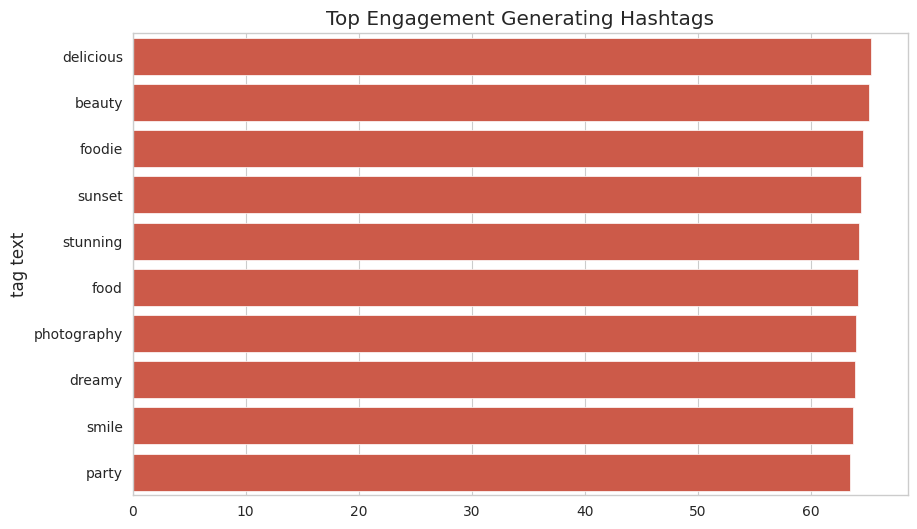

In [43]:
hashtag_engagement = hashtags.merge(
    engagement,
    left_on='photo',
    right_on='id'
)

top_engagement_tags = (
    hashtag_engagement.groupby('tag text')
    ['engagement_score']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_engagement_tags.values,
    y=top_engagement_tags.index
)

plt.title('Top Engagement Generating Hashtags')

plt.show()

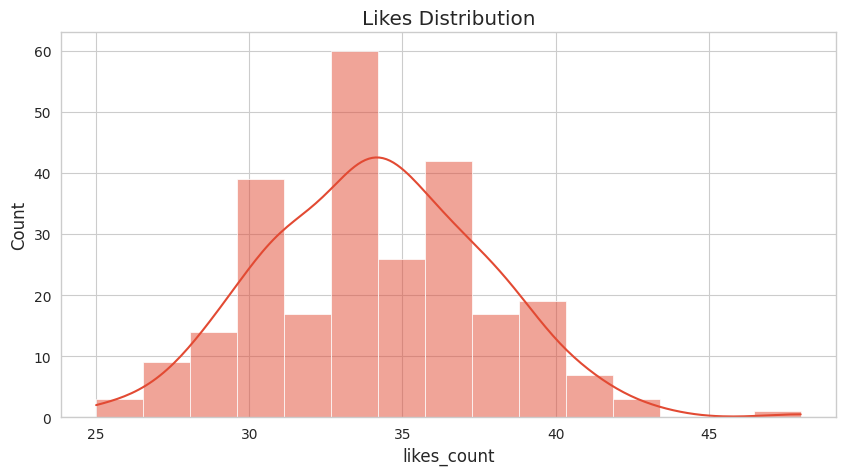

In [44]:
plt.figure(figsize=(10,5))

sns.histplot(
    engagement['likes_count'],
    bins=15,
    kde=True
)

plt.title('Likes Distribution')

plt.show()

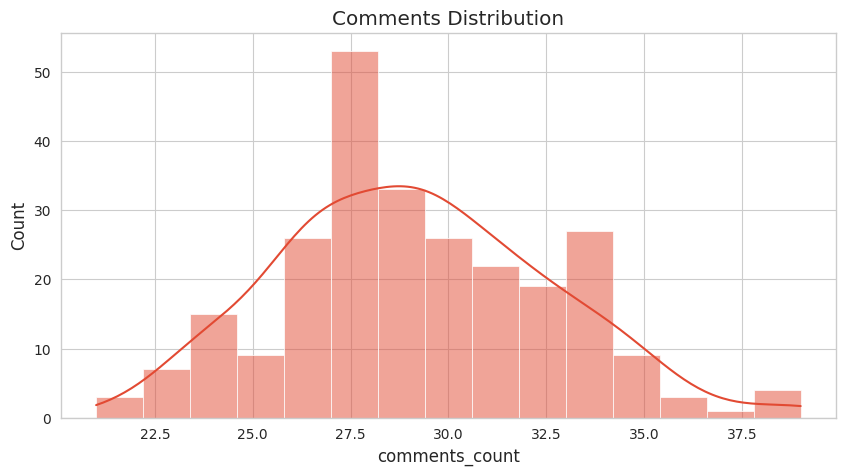

In [45]:
plt.figure(figsize=(10,5))

sns.histplot(
    engagement['comments_count'],
    bins=15,
    kde=True
)

plt.title('Comments Distribution')

plt.show()

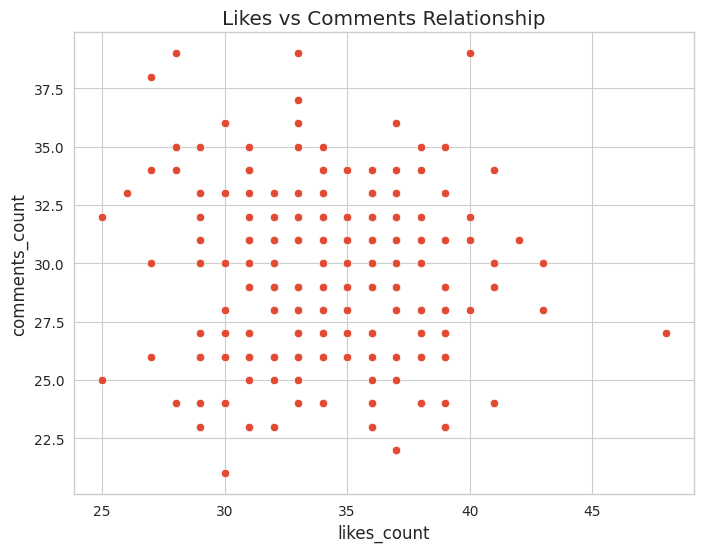

In [46]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=engagement,
    x='likes_count',
    y='comments_count'
)

plt.title('Likes vs Comments Relationship')

plt.show()

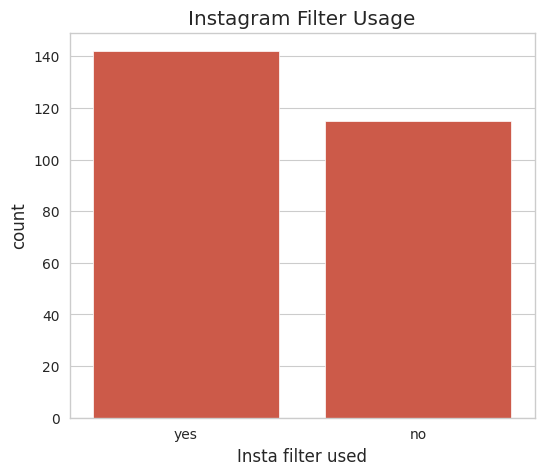

In [47]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=photos,
    x='Insta filter used'
)

plt.title('Instagram Filter Usage')

plt.show()

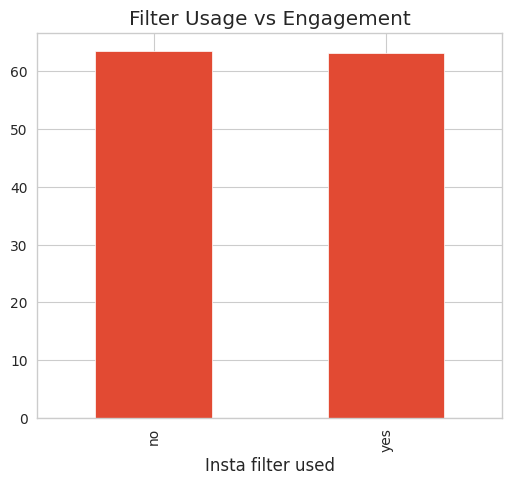

In [48]:
filter_engagement = engagement.groupby(
    'Insta filter used'
)['engagement_score'].mean()

plt.figure(figsize=(6,5))

filter_engagement.plot(
    kind='bar'
)

plt.title('Filter Usage vs Engagement')

plt.show()

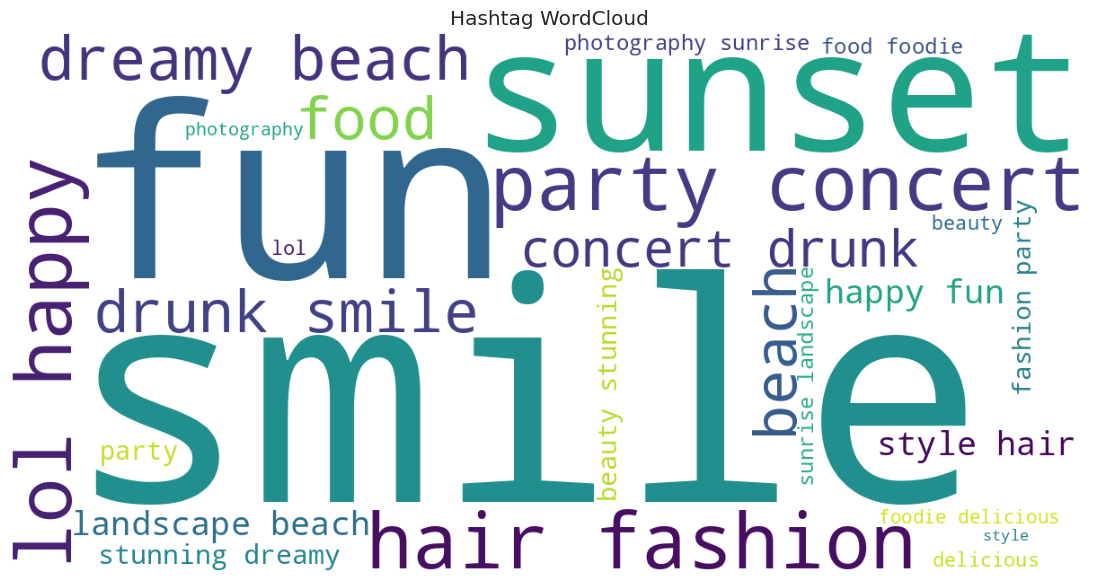

In [49]:
text = " ".join(
    hashtags['tag text']
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Hashtag WordCloud")

plt.show()

# Executive Summary

This project analyzes Instagram user engagement data to identify content patterns, hashtag effectiveness, and factors influencing engagement. The dataset consists of user profiles, posts, likes, comments, hashtags, and follower relationships.

The analysis focused on engagement metrics, content type performance, hashtag popularity, and user interaction patterns. Results indicate that photo-based content generated the highest engagement compared to video and carousel posts. Hashtags such as #delicious, #beauty, and #foodie achieved higher average engagement levels.

The findings were used to develop a content strategy and actionable recommendations for Alfido Tech to improve social media engagement, brand visibility, and audience interaction.
